# 1. What is EDA?

## Concept

Exploratory Data Analysis (EDA) is the process of understanding a dataset before applying Machine Learning.

It involves checking the structure, data types, missing values, duplicates, distributions, outliers, relationships, and important patterns in the data.

## Example

In the Titanic dataset, EDA helps us understand passenger age, sex, passenger class, fare, and their relationship with survival.

## Interpretation

EDA gives us a clear picture of the dataset before making Machine Learning decisions.

## Insight

EDA helps identify both useful information and possible data problems.

## AI/ML Relevance

EDA is an important first step because a Machine Learning model depends on the quality and understanding of the input data.

In [1]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

print("Dataset loaded successfully.")
print(df.shape)

Dataset loaded successfully.
(891, 12)


# 2. Why is EDA Performed Before Machine Learning?

## Concept

EDA is performed before Machine Learning to understand the data and identify problems that may affect the model.

## Example

In the Titanic dataset, EDA can identify missing Age values, categorical features such as Sex, and unusual Fare values.

## Interpretation

Without EDA, we may provide poor-quality or incorrectly prepared data to the Machine Learning model.

## Insight

EDA helps us make informed decisions about preprocessing and feature selection.

## AI/ML Relevance

EDA improves our understanding of the dataset and helps prepare better features for Machine Learning.

In [2]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


# 3. Univariate, Bivariate, and Multivariate Analysis

## Concept

**Univariate Analysis** studies one variable at a time.

**Bivariate Analysis** studies the relationship between two variables.

**Multivariate Analysis** studies relationships among three or more variables.

## Example

- Univariate: Analyze the distribution of Age.
- Bivariate: Analyze Age and Fare together.
- Multivariate: Analyze Age, Fare, Pclass, and Survived together.

## Interpretation

The three methods help us understand individual features, relationships, and multiple-feature interactions.

## Insight

Using these methods together gives a more complete understanding of the dataset.

## AI/ML Relevance

These analyses help identify useful features, relationships, patterns, and possible feature interactions.

In [3]:
# Univariate
print(df["Age"].describe())

# Bivariate
print(df[["Age", "Fare"]].corr())

# Multivariate
print(df[["Age", "Fare", "Pclass", "Survived"]].corr())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
           Age      Fare
Age   1.000000  0.096067
Fare  0.096067  1.000000
               Age      Fare    Pclass  Survived
Age       1.000000  0.096067 -0.369226 -0.077221
Fare      0.096067  1.000000 -0.549500  0.257307
Pclass   -0.369226 -0.549500  1.000000 -0.338481
Survived -0.077221  0.257307 -0.338481  1.000000


# 4. How Do You Identify Missing Values?

## Concept

Missing values are observations where information is not available.

## Example

In the Titanic dataset, some passengers do not have an Age or Cabin value.

## Interpretation

We can count missing values for every column and calculate their percentage.

## Insight

Identifying missing values helps us decide what needs attention during preprocessing.

## AI/ML Relevance

Missing values can affect analysis and may cause problems for Machine Learning algorithms.

In [4]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

print(missing[missing["Missing Count"] > 0].round(2))

          Missing Count  Missing Percentage
Age                 177               19.87
Cabin               687               77.10
Embarked              2                0.22


# 5. How Do You Identify Duplicate Records?

## Concept

Duplicate records are rows that contain the same information and appear more than once.

## Example

If the same passenger record appears twice, it may be a duplicate.

## Interpretation

The `duplicated()` function can identify completely duplicated rows.

## Insight

Duplicates should be investigated before deciding whether they should be removed.

## AI/ML Relevance

Duplicate records can give repeated observations more influence during model training.

In [5]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


# 6. What is an Outlier?

## Concept

An outlier is an observation that is unusually far from most other observations.

## Example

In the Titanic dataset, a very high Fare can be considered a potential outlier.

## Interpretation

An outlier is not automatically an error. It may represent a genuine and unusual observation.

## Insight

Outliers should be investigated before deciding whether to remove, transform, or retain them.

## AI/ML Relevance

Outliers can affect statistical analysis and some Machine Learning algorithms.

In [6]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

outliers = df[
    (df["Fare"] < Q1 - 1.5 * IQR) |
    (df["Fare"] > Q3 + 1.5 * IQR)
]

print("Potential Fare outliers:", len(outliers))

Potential Fare outliers: 116


# 7. IQR Method

## Concept

The Interquartile Range (IQR) measures the spread of the middle 50% of the data.

IQR = Q3 - Q1

Values below Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR are commonly treated as potential outliers.

## Example

We can use the IQR method to identify unusually high or low Fare values in the Titanic dataset.

## Interpretation

The method provides a simple way to detect potential outliers without assuming that the data follows a normal distribution.

## Insight

The IQR method is useful for identifying unusual numerical observations.

## AI/ML Relevance

It helps identify data points that may need investigation before model training.

In [7]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

Lower Bound: -26.724
Upper Bound: 65.6344


# 8. What is Skewness?

## Concept

Skewness describes the asymmetry of a numerical distribution.

A distribution can be approximately symmetric, right-skewed, or left-skewed.

## Example

Fare in the Titanic dataset is a useful feature for checking skewness.

## Interpretation

A positive skew generally means the distribution has a longer right tail, while a negative skew means a longer left tail.

## Insight

Skewness helps us understand the shape of numerical features.

## AI/ML Relevance

Highly skewed features may require transformation depending on the Machine Learning algorithm.

In [8]:
print("Age Skewness:", round(df["Age"].skew(), 2))
print("Fare Skewness:", round(df["Fare"].skew(), 2))

Age Skewness: 0.39
Fare Skewness: 4.79


# 9. What is Correlation?

## Concept

Correlation measures the strength and direction of a linear relationship between two numerical variables.

The correlation value ranges from -1 to +1.

## Example

We can examine the correlation between Fare and Survived in the Titanic dataset.

## Interpretation

A positive value indicates a positive relationship, while a negative value indicates a negative relationship.

## Insight

Correlation helps identify variables that may have meaningful relationships.

## AI/ML Relevance

Correlation analysis can support feature selection and help identify potentially related features.

In [9]:
correlation = df[["Fare", "Survived"]].corr()

print(correlation)

              Fare  Survived
Fare      1.000000  0.257307
Survived  0.257307  1.000000


# 10. Correlation vs Causation

## Concept

Correlation means two variables are related, while causation means one variable directly causes a change in another variable.

## Example

If passenger class and survival are related in the Titanic dataset, this does not prove that passenger class alone caused the survival outcome.

## Interpretation

A relationship between variables should not automatically be treated as a cause-and-effect relationship.

## Insight

Correlation helps us find patterns, but additional evidence is required to establish causation.

## AI/ML Relevance

Understanding this difference prevents incorrect conclusions when interpreting Machine Learning features and results.

In [10]:
print(df[["Pclass", "Survived"]].corr())

            Pclass  Survived
Pclass    1.000000 -0.338481
Survived -0.338481  1.000000


# 11. What is Multicollinearity?

## Concept

Multicollinearity occurs when two or more input features are strongly related to each other.

## Example

If two features contain very similar information, they may provide redundant information to a model.

## Interpretation

A correlation matrix can help identify strongly related numerical features.

## Insight

Highly correlated features should be investigated before model development.

## AI/ML Relevance

Multicollinearity can make some models difficult to interpret and can affect coefficient estimates.

In [11]:
features = ["Age", "SibSp", "Parch", "Fare", "Pclass"]

print(df[features].corr().round(2))

         Age  SibSp  Parch  Fare  Pclass
Age     1.00  -0.31  -0.19  0.10   -0.37
SibSp  -0.31   1.00   0.41  0.16    0.08
Parch  -0.19   0.41   1.00  0.22    0.02
Fare    0.10   0.16   0.22  1.00   -0.55
Pclass -0.37   0.08   0.02 -0.55    1.00


# 12. How Do You Identify Class Imbalance?

## Concept

Class imbalance occurs when one target class contains significantly more observations than another class.

## Example

The Titanic target variable `Survived` contains two classes: 0 and 1.

## Interpretation

We can use value counts and percentages to understand the class distribution.

## Insight

If one class is much larger than the other, accuracy alone may not provide a complete picture of model performance.

## AI/ML Relevance

Class imbalance should be considered when selecting evaluation metrics and preprocessing techniques.

In [12]:
class_counts = df["Survived"].value_counts()
class_percentages = df["Survived"].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentages:")
print(class_percentages.round(2))

Class Counts:
Survived
0    549
1    342
Name: count, dtype: int64

Class Percentages:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


# 13. Why Should Outliers Not Always Be Removed?

## Concept

An outlier is not necessarily an error. It can be a genuine and important observation.

## Example

A passenger with an unusually high Fare may represent a real premium ticket rather than an incorrect value.

## Interpretation

Before removing an outlier, we should determine whether it is a data-entry error or a genuine observation.

## Insight

The correct action may be to retain, transform, cap, or remove the observation depending on the reason for the outlier.

## AI/ML Relevance

Automatically removing valid observations can result in information loss and may reduce model quality.

In [13]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1

potential_outliers = df[df["Fare"] > Q3 + 1.5 * IQR]

print(potential_outliers[["PassengerId", "Fare"]].head())

    PassengerId      Fare
1             2   71.2833
27           28  263.0000
31           32  146.5208
34           35   82.1708
52           53   76.7292


# 14. Create a Correlation Heatmap

## Concept

A correlation heatmap provides a visual representation of relationships between numerical variables.

## Example

The Titanic dataset can be used to compare Age, Fare, Pclass, family-related variables, and Survived.

## Interpretation

The strength and direction of relationships can be quickly identified from the heatmap.

## Insight

The heatmap makes it easier to identify potentially strong or weak relationships.

## AI/ML Relevance

Correlation analysis can support feature selection and help identify possible multicollinearity.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

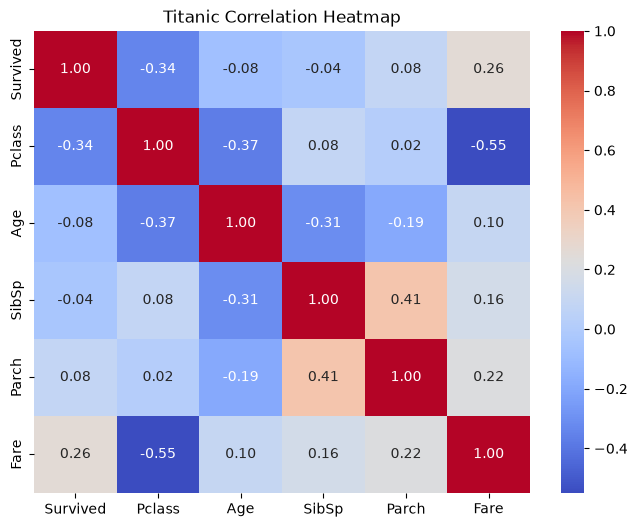

In [16]:
features = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]

plt.figure(figsize=(8, 6))

sns.heatmap(
    df[features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Titanic Correlation Heatmap")
plt.show()

# 15. Detect Outliers Using IQR

## Concept

The IQR method identifies potential outliers using the first and third quartiles.

## Example

We can apply the method to the Fare column.

## Interpretation

Values outside the calculated lower and upper boundaries are considered potential outliers.

## Insight

The result should be investigated before deciding on any treatment.

## AI/ML Relevance

Outlier detection helps identify observations that may influence Machine Learning models.

In [18]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of potential outliers: 116


In [19]:
outliers[["Fare"]].head(10)

,Fare
1,71.2833
27,263.0000
31,146.5208
34,82.1708
52,76.7292
61,80.0000
62,83.4750
72,73.5000
88,263.0000
102,77.2875


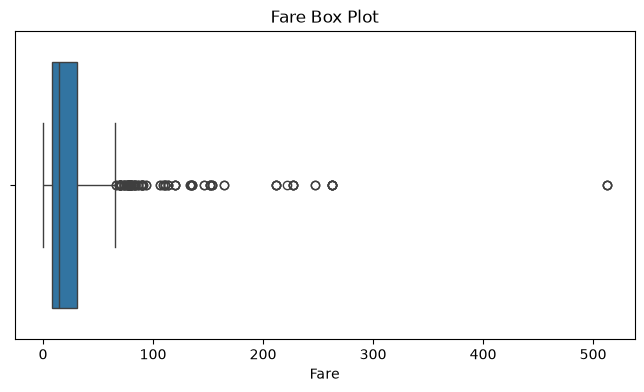

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["Fare"])
plt.title("Fare Box Plot")
plt.show()

# 16. Analyze the Distribution of a Numerical Feature

## Concept

Distribution analysis helps us understand the shape, center, spread, and skewness of a numerical variable.

## Example

The Age feature can be analyzed using a histogram and density curve.

## Interpretation

The graph shows how passenger ages are distributed.

## Insight

The distribution helps identify concentration, spread, and possible unusual values.

## AI/ML Relevance

Understanding feature distributions helps determine whether transformation or scaling may be useful during preprocessing.

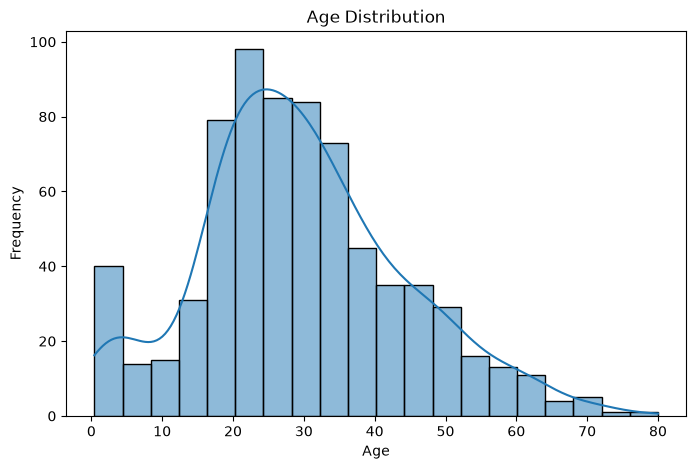

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Age"].dropna(), kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# 17. Perform Categorical Analysis

## Concept

Categorical analysis examines the unique categories and frequency of each category.

## Example

The Sex column contains categorical values representing male and female passengers.

## Interpretation

Value counts show how many observations belong to each category.

## Insight

The distribution of categories helps us understand the composition of the dataset.

## AI/ML Relevance

Categorical features generally need appropriate encoding before they are used by many Machine Learning algorithms.

In [22]:
print("Unique Categories:")
print(df["Sex"].unique())

print("\nCategory Frequencies:")
print(df["Sex"].value_counts())

print("\nCategory Percentages:")
print((df["Sex"].value_counts(normalize=True) * 100).round(2))

Unique Categories:
<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Category Frequencies:
Sex
male      577
female    314
Name: count, dtype: int64

Category Percentages:
Sex
male      64.76
female    35.24
Name: proportion, dtype: float64


# 18. Generate a Complete EDA Summary

## Concept

A complete EDA summary combines dataset structure, data quality, numerical analysis, categorical analysis, distributions, outliers, and relationships.

## Example

The Titanic dataset can be summarized using its dimensions, missing values, duplicates, numerical statistics, and correlations.

## Interpretation

A complete summary provides a quick overview of the important characteristics and potential problems in the dataset.

## Insight

EDA helps us understand the dataset before making preprocessing and Machine Learning decisions.

## AI/ML Relevance

A complete EDA summary provides a strong foundation for the next preprocessing and Machine Learning stages.

In [23]:
print("=== DATASET OVERVIEW ===")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATES ===")
print(df.duplicated().sum())

print("\n=== NUMERICAL SUMMARY ===")
print(df.describe().round(2))

print("\n=== TARGET DISTRIBUTION ===")
print(df["Survived"].value_counts())

=== DATASET OVERVIEW ===
Rows: 891
Columns: 12

=== DATA TYPES ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

=== MISSING VALUES ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

=== DUPLICATES ===
0

=== NUMERICAL SUMMARY ===
       PassengerId  Survived  Pclass     Age   SibSp   Parch    Fare
count       891.00    891.00  891.00  714.00  891.00  891.00  891.00
mean        446.00      0.38    2.31   29.70    0.52    0.38   32.20
std         257.35      0.49    0.84   14.53    1.10    0.81   49.69
min           1.00      0.00    1.00    0.42    0.00 

# Mini Assessment Conclusion

This assessment covered the important concepts of Exploratory Data Analysis using the Titanic dataset.

The questions covered:

- EDA and its importance
- Univariate, bivariate, and multivariate analysis
- Missing values
- Duplicate records
- Outliers and the IQR method
- Skewness
- Correlation and causation
- Multicollinearity
- Class imbalance
- Correlation heatmap
- Numerical distribution analysis
- Categorical analysis
- Complete EDA summary

The main objective of EDA is to understand the data, identify potential problems, discover useful patterns, and prepare for the next stage of Machine Learning.

The identified issues should be addressed during preprocessing rather than automatically changing the data during EDA.